# 📊 Analisis Customer Baru (New Customer Analysis)

Analisis ini melacak pertumbuhan customer baru dari waktu ke waktu.

**Data source:** `customers.csv`

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load Data dari CSV

In [11]:
# Tentukan path file
base_path = '/Users/user/Documents/03 KERJA/PT Multimedia Solusi Prima/2026/APRIL/Arbas Market Intelligence - Data/Dashboardanlys/'

# Load customer data
df_customers = pd.read_csv(os.path.join(base_path, 'customers.csv'))

# Tampilkan info dasar
print(f"✅ Total Records: {len(df_customers):,}")
print(f"\n📋 Columns: {list(df_customers.columns)}")
print(f"\n🔍 Sample Data:")
df_customers

✅ Total Records: 4,225

📋 Columns: ['id', 'customerCode', 'nama', 'alamat', 'type', 'umur', 'jenisKelamin', 'provinsi', 'kota', 'contactPerson', 'telp', 'tipeChannel', 'ukuranOutlet', 'capacityM3PerMonth', 'awalKontrak', 'akhirKontrak', 'status', 'featureId', 'geom', 'createdAt', 'updatedAt', 'createdById']

🔍 Sample Data:


,id,customerCode,nama,alamat,type,umur,jenisKelamin,provinsi,kota,contactPerson,telp,tipeChannel,ukuranOutlet,capacityM3PerMonth,awalKontrak,akhirKontrak,status,featureId,geom,createdAt,updatedAt,createdById
0,ed0fdd3f-cf8d-4445-91c2-8790e758abcf,BRTOK001,TOKO ARYA,"6CVC+FF Maguwoharjo, Sleman Regency, Special R...",B2B,NaN,NaN,NaN,NaN,NaN,NaN,RUKO_SRC,NaN,NaN,2026-01-01 00:00:00,2028-01-01 00:00:00,Active,1000001,0101000020E6100000FA7E6ABCF49A5B405839B4C87606...,2026-03-06 06:49:39.752,2026-03-06 06:49:39.752,31499f31-7d13-475d-a8c8-880d4bf09cf4
1,3ac8f3e5-0ab4-4429-9e49-73372e594bc1,BRTOK002,TOKO TM GROSIR,"78J3+33W, Kebonagung Kasuran, Pete, Margodadi,...",B2B,NaN,NaN,NaN,NaN,NaN,NaN,RUKO_SRC,NaN,NaN,2026-01-01 00:00:00,2028-01-01 00:00:00,Active,1000002,0101000020E610000076B9D27C5F935B407E8CB96B09E1...,2026-03-06 06:49:39.763,2026-03-06 06:49:39.763,31499f31-7d13-475d-a8c8-880d4bf09cf4
2,4799f33b-c1ee-4ae0-a3bc-247223a1e01b,BSBEN001,BENGKEL AHASS SETURAN,"6CJ5+5W Condong Catur, Sleman Regency, Special...",B2B,NaN,NaN,Daerah Istimewa Yogyakarta,SLEMAN,NaN,NaN,SHOWROOM_BENGKEL,SMALL,0.0,2026-01-01 00:00:00,2028-01-01 00:00:00,active,1000012,0101000020E61000007D3F355E3A9A5B4079E926310814...,2026-03-06 06:49:39.79,2026-03-12 01:46:26.308,31499f31-7d13-475d-a8c8-880d4bf09cf4
3,d4256ed3-42e6-4b89-819a-79b58c3da83d,BLKYO001,KYOKEN BOTOL JOGJA,"JL. SORAGAN ,SUMBERAN, MIROTA GODEAN KESELATAN...",B2B,NaN,NaN,YOGYAKARTA,SLEMAN,NaN,NaN,GROSIR,MEDIUM,0.0,2026-01-01 00:00:00,2028-01-01 00:00:00,active,1000013,0101000020E610000060E5D0225B965B40CFF753E3A523...,2026-03-06 06:49:39.792,2026-03-11 02:41:40.861,31499f31-7d13-475d-a8c8-880d4bf09cf4
4,22a1f233-375b-4956-be95-82398537c5db,BKCVD001,CV DARMA PRINGGA BIRAMA,"Jl. Dukuh Pilangsari, Dusun III, Gondang, Kec....",B2B,NaN,NaN,Jawa Tengah,Klaten,NaN,NaN,LAINNYA,NaN,0.0,2026-01-01 00:00:00,2028-01-01 00:00:00,active,1000015,0101000020E61000006DE7FBA971A45B40A245B6F3FDDC...,2026-03-06 06:49:39.797,2026-03-10 04:31:18.921,31499f31-7d13-475d-a8c8-880d4bf09cf4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,fd8b7537-817a-4d22-8703-535bf44fa448,BOTUM001,TUMBUH BERSAMA,Maguwoharjo,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004215,NaN,2026-04-11 09:07:15.775,2026-04-11 09:07:15.775,c839fe99-ec2c-4b7e-814a-60d399884231
4221,c727e23f-3f6f-4806-bdf6-bb974dc36a2a,BOSPP009,SPPG NGAGLIK 2,Ngaglik,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004216,NaN,2026-04-11 09:46:25.235,2026-04-11 09:46:25.235,c839fe99-ec2c-4b7e-814a-60d399884231
4222,0e1b186b-32e1-418d-8944-7537e28d79ea,BOSPP010,SPPG KALASAN 2,Kalasan,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004217,NaN,2026-04-11 11:37:15.735,2026-04-11 11:37:15.735,c839fe99-ec2c-4b7e-814a-60d399884231
4223,6c5612f6-abb7-4613-af1c-2bd57f8ca1a3,BOMIP001,MI PANDANARAN,Pandanaran,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,SEKOLAH,NaN,0.0,NaN,NaN,active,1004218,NaN,2026-04-13 02:20:53.67,2026-04-13 02:20:53.67,c839fe99-ec2c-4b7e-814a-60d399884231


In [13]:
# Parse createdAt menjadi datetime
df_customers['createdAt'] = pd.to_datetime(df_customers['createdAt'], format='mixed')

# Cek rentang tanggal
print(f"📅 Tanggal pertama: {df_customers['createdAt'].min()}")
print(f"📅 Tanggal terakhir: {df_customers['createdAt'].max()}")
print(f"📅 Range: {(df_customers['createdAt'].max() - df_customers['createdAt'].min()).days} hari")

📅 Tanggal pertama: 2026-03-06 06:49:39.752000
📅 Tanggal terakhir: 2026-04-13 03:06:19.940000
📅 Range: 37 hari


## 2. Statistik Dasar Customer Baru

In [14]:
# Statistik Dasar Customer Baru

now = pd.Timestamp.now()
df_customers['days_since_creation'] = (now - df_customers['createdAt']).dt.days

print("=" * 60)
print("📊 STATISTIK DASAR CUSTOMER BARU")
print("=" * 60)

# User baru hari ini
today_new = df_customers[df_customers['createdAt'].dt.date == now.date()]
print(f"\n🆕 Customer baru HARI INI: {len(today_new)}")

# User baru 7 hari terakhir
week_new = df_customers[df_customers['createdAt'] >= now - timedelta(days=7)]
print(f"📅 Customer baru 7 hari terakhir: {len(week_new)}")

# User baru 30 hari terakhir
month_new = df_customers[df_customers['createdAt'] >= now - timedelta(days=30)]
print(f"🗓️ Customer baru 30 hari terakhir: {len(month_new)}")

# User baru 90 hari terakhir
quarter_new = df_customers[df_customers['createdAt'] >= now - timedelta(days=90)]
print(f"📆 Customer baru 90 hari terakhir: {len(quarter_new)}")

📊 STATISTIK DASAR CUSTOMER BARU

🆕 Customer baru HARI INI: 0
📅 Customer baru 7 hari terakhir: 0
🗓️ Customer baru 30 hari terakhir: 156
📆 Customer baru 90 hari terakhir: 4225


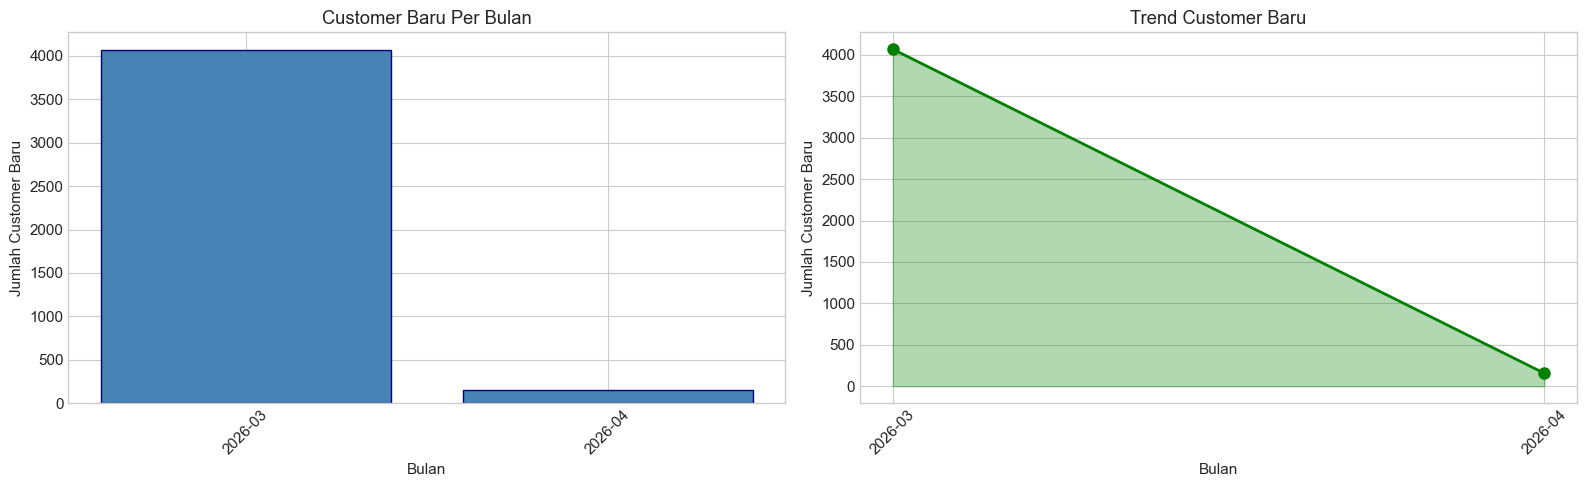


📈 Data Bulanan:


,year_month,new_customers,growth_pct
0,2026-03,4069,NaN
1,2026-04,156,-96.166134


In [16]:
# Grafik: Trend Customer Baru Per Bulan

df_customers['year_month'] = df_customers['createdAt'].dt.to_period('M')

monthly_new = df_customers.groupby('year_month').size().reset_index(name='new_customers')
monthly_new['year_month'] = monthly_new['year_month'].astype(str)

# Calculate growth
monthly_new['growth_pct'] = monthly_new['new_customers'].pct_change() * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart - New customers per month
axes[0].bar(monthly_new['year_month'], monthly_new['new_customers'], color='steelblue', edgecolor='navy')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Customer Baru')
axes[0].set_title('Customer Baru Per Bulan')
axes[0].tick_params(axis='x', rotation=45)

# Line chart - Growth trend
axes[1].plot(monthly_new['year_month'], monthly_new['new_customers'], 
             marker='o', linewidth=2, color='green', markersize=8)
axes[1].fill_between(monthly_new['year_month'], monthly_new['new_customers'], 
                     alpha=0.3, color='green')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Jumlah Customer Baru')
axes[1].set_title('Trend Customer Baru')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('new_customers_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📈 Data Bulanan:")
monthly_new

## 3. Breakdown per Channel (Tipe)

In [17]:
# Cek kolom yang tersedia
print("Kolom yang tersedia:")
for col in df_customers.columns:
    print(f"  - {col}")

Kolom yang tersedia:
  - id
  - customerCode
  - nama
  - alamat
  - type
  - umur
  - jenisKelamin
  - provinsi
  - kota
  - contactPerson
  - telp
  - tipeChannel
  - ukuranOutlet
  - capacityM3PerMonth
  - awalKontrak
  - akhirKontrak
  - status
  - featureId
  - geom
  - createdAt
  - updatedAt
  - createdById
  - days_since_creation
  - year_month


In [18]:
# Breakdown berdasarkan tipeChannel

if 'tipeChannel' in df_customers.columns:
    channel_col = 'tipeChannel'
elif 'type' in df_customers.columns:
    channel_col = 'type'
else:
    channel_col = df_customers.columns[3]  # fallback

print(f"Menggunakan kolom: {channel_col}")

channel_breakdown = df_customers.groupby(channel_col).agg(
    total_customers=('id', 'count'),
    new_last_30d=('createdAt', lambda x: (x >= now - timedelta(days=30)).sum()),
    new_last_90d=('createdAt', lambda x: (x >= now - timedelta(days=90)).sum())
).reset_index()

channel_breakdown['pct_from_total'] = (channel_breakdown['total_customers'] / channel_breakdown['total_customers'].sum() * 100).round(2)
channel_breakdown = channel_breakdown.sort_values('total_customers', ascending=False)

print("\n📊 Breakdown Customer per Channel:")
channel_breakdown

Menggunakan kolom: tipeChannel

📊 Breakdown Customer per Channel:


,tipeChannel,total_customers,new_last_30d,new_last_90d,pct_from_total
19,LAINNYA,800,37,800,20.93
40,TOKO,298,5,298,7.80
27,RUKO_SRC,273,0,273,7.14
14,KANTOR_PERUSAHAAN,247,9,247,6.46
24,RESTORAN,205,8,205,5.36
29,RUMAH_TANGGA,199,23,199,5.21
5,CAFE,132,0,132,3.45
3,BENGKEL,114,4,114,2.98
0,APOTEK,110,2,110,2.88
38,TEMPAT_IBADAH,102,0,102,2.67


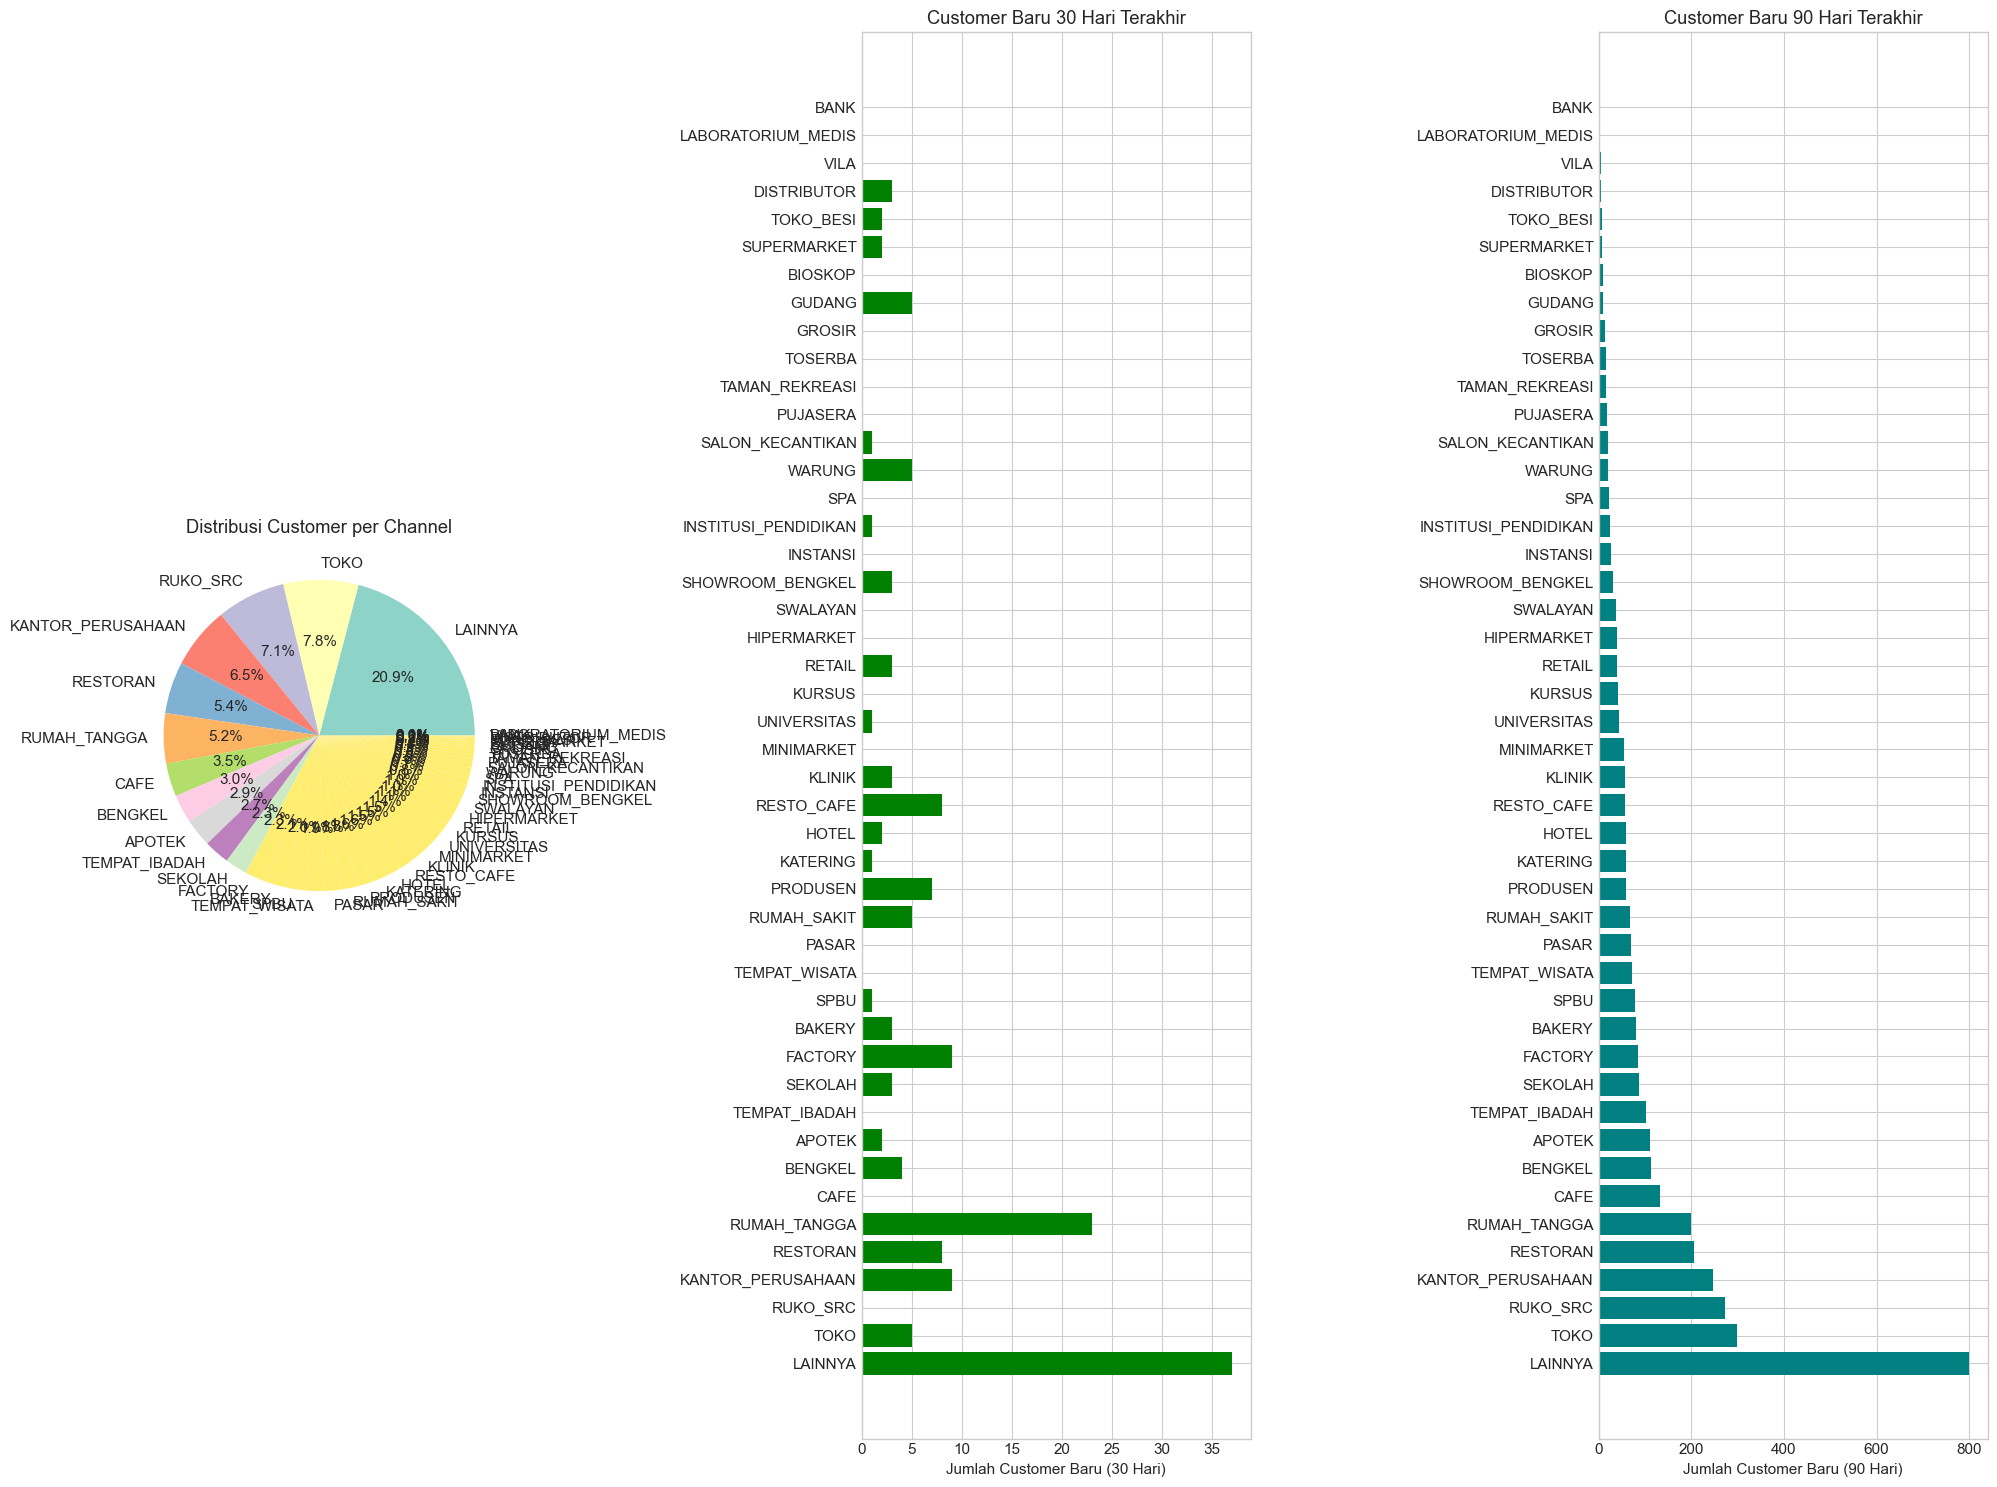

In [21]:
# Visualisasi Breakdown per Channel

fig, axes = plt.subplots(1, 3, figsize=(20, 15))

# Pie chart - Distribution
colors = plt.cm.Set3(range(len(channel_breakdown)))
axes[0].pie(channel_breakdown['total_customers'], 
            labels=channel_breakdown[channel_col],
            autopct='%1.1f%%', 
            colors=colors)
axes[0].set_title('Distribusi Customer per Channel')

# Bar chart - New customers 30 days
colors_bar = ['green' if x > 0 else 'red' for x in channel_breakdown['new_last_30d']]
axes[1].barh(channel_breakdown[channel_col], channel_breakdown['new_last_30d'], color=colors_bar)
axes[1].set_xlabel('Jumlah Customer Baru (30 Hari)')
axes[1].set_title('Customer Baru 30 Hari Terakhir')

# Bar chart - New customers 90 days
axes[2].barh(channel_breakdown[channel_col], channel_breakdown['new_last_90d'], color='teal')
axes[2].set_xlabel('Jumlah Customer Baru (90 Hari)')
axes[2].set_title('Customer Baru 90 Hari Terakhir')

plt.tight_layout()
plt.savefig('customer_channel_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Breakdown per Provinsi

In [22]:
# Tentukan kolom provinsi
province_col = None
for col in ['provinsi', 'Provinsi', 'province']:
    if col in df_customers.columns:
        province_col = col
        break

if province_col:
    province_breakdown = df_customers.groupby(province_col).agg(
        total_customers=('id', 'count'),
        new_last_30d=('createdAt', lambda x: (x >= now - timedelta(days=30)).sum())
    ).reset_index()
    
    province_breakdown = province_breakdown.sort_values('total_customers', ascending=False).head(15)
    
    print(f"📍 Top 15 Provinsi (berdasarkan kolom '{province_col}'):")
    province_breakdown
else:
    print("⚠️ Kolom provinsi tidak ditemukan")
    province_breakdown = pd.DataFrame()

📍 Top 15 Provinsi (berdasarkan kolom 'provinsi'):


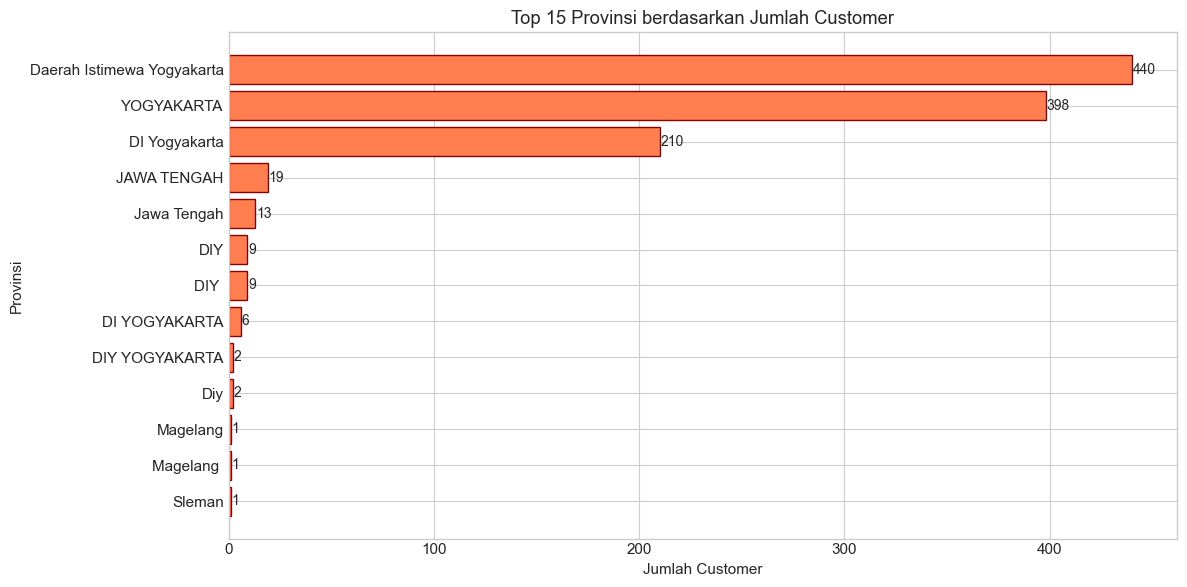

In [23]:
# Visualisasi Top Provinsi

if not province_breakdown.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.barh(province_breakdown[province_col], province_breakdown['total_customers'], 
                   color='coral', edgecolor='darkred')
    
    # Add value labels
    for bar, val in zip(bars, province_breakdown['total_customers']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val}', va='center', fontsize=10)
    
    ax.set_xlabel('Jumlah Customer')
    ax.set_ylabel('Provinsi')
    ax.set_title('Top 15 Provinsi berdasarkan Jumlah Customer')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('customer_by_province.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Analisis Cohort - Retensi Customer Baru

In [24]:
# Load transaction data untuk cohort analysis
df_trans = pd.read_csv(os.path.join(base_path, 'Transaction.csv'))

print(f"✅ Total Transaksi: {len(df_trans):,}")
print(f"\n📋 Columns: {list(df_trans.columns)}")
df_trans.head()

✅ Total Transaksi: 523

📋 Columns: ['id', 'billNo', 'date', 'qty', 'price', 'total', 'paymentType', 'channel', 'sales', 'notes', 'status', 'customerId', 'productId', 'geom', 'createdAt', 'updatedAt']


,id,billNo,date,qty,price,total,paymentType,channel,sales,notes,status,customerId,productId,geom,createdAt,updatedAt
0,46f1858d-ac29-48bf-840f-051136d3911e,TRX-2026-00001,2026-03-11 00:00:00,4,7500,30000,CREDIT,CAFE,AKHMAD KHOIRUL BARIUSYAFI,NaN,PENDING,648db366-b787-407e-8531-4501a101b102,859ce3a9-14d2-4e7e-ac78-2e2ccf13bc09,NaN,2026-03-11 03:55:16.353,2026-03-11 03:55:16.353
1,046b41b0-e1ae-4743-b09b-fb9b7ebd0455,TRX-2026-00002,2026-03-11 00:00:00,13,11000,143000,CASH,TOKO,AKHMAD KHOIRUL BARIUSYAFI,NaN,PAID,f8b1e3bf-b75d-4e9d-96a9-f7d76b6db9a4,859ce3a9-14d2-4e7e-ac78-2e2ccf13bc09,NaN,2026-03-11 04:21:40.33,2026-03-11 04:21:40.33
2,e7066fc8-e784-42a5-b36a-22b9454a53b3,TRX-2026-00003,2026-03-11 00:00:00,7,10000,70000,TRANSFER,LAINNYA,AKHMAD KHOIRUL BARIUSYAFI,NaN,PENDING,f5a9206f-35ed-46e2-a128-967963cb89f7,859ce3a9-14d2-4e7e-ac78-2e2ccf13bc09,NaN,2026-03-11 04:46:56.897,2026-03-11 04:46:56.897
3,fc494580-04f2-4599-bef7-672be684d57e,TRX-2026-00005,2026-03-11 00:00:00,5,20000,100000,CREDIT,TOKO,LATHIEF NUR S,220ml : 5,PAID,c13c9f24-111f-4a05-8b66-ad41acb2aa20,7dc69f73-0423-4334-8034-c3fd9ab9eb5b,NaN,2026-03-11 04:59:53.319,2026-03-14 15:23:37.474
4,b501d5ec-0d18-4985-99cb-bb8d97748fdc,TRX-2026-00006,2026-03-11 00:00:00,40,12000,480000,CREDIT,LAINNYA,SUDARYONO,NaN,PENDING,96b8bcad-51d4-48f8-9e53-47ce923668bb,859ce3a9-14d2-4e7e-ac78-2e2ccf13bc09,NaN,2026-03-11 05:05:39.189,2026-03-11 05:05:39.189


In [25]:
# Parse tanggal transaksi
date_col = 'date' if 'date' in df_trans.columns else 'Date'
df_trans[date_col] = pd.to_datetime(df_trans[date_col])

# Tentukan customer id column
cust_id_col = 'customerId' if 'customerId' in df_trans.columns else 'customer_id'
print(f"Customer ID column: {cust_id_col}")

Customer ID column: customerId


In [26]:
# Cohort Retention Analysis

# Gabungkan customer creation date dengan transaksi
df_cohort = df_customers.merge(
    df_trans[[cust_id_col, date_col]],
    left_on='id',
    right_on=cust_id_col,
    how='left'
)

# Tentukan cohort bulan (bulan pertama kali dibuat)
df_cohort['cohort_month'] = df_cohort['createdAt'].dt.to_period('M')
df_cohort['transaction_month'] = df_cohort[date_col].dt.to_period('M')

# Hitung selisih bulan (month number)
df_cohort['months_since_creation'] = (
    (df_cohort['transaction_month'].astype('int') - df_cohort['cohort_month'].astype('int'))
).fillna(0).astype(int)

# Filter yang ada transaksi
df_cohort = df_cohort.dropna(subset=[date_col])

# Hitung retention
cohort_pivot = df_cohort.groupby(['cohort_month', 'months_since_creation'])['id'].nunique().unstack(fill_value=0)

# Hitung retention rate
cohort_size = df_cohort.groupby('cohort_month')['id'].nunique()
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

print("📊 Retention Rate (%):")
retention_matrix.round(2)

📊 Retention Rate (%):


months_since_creation,0,1
cohort_month,,
2026-03,48.29,66.16
2026-04,100.00,0.00


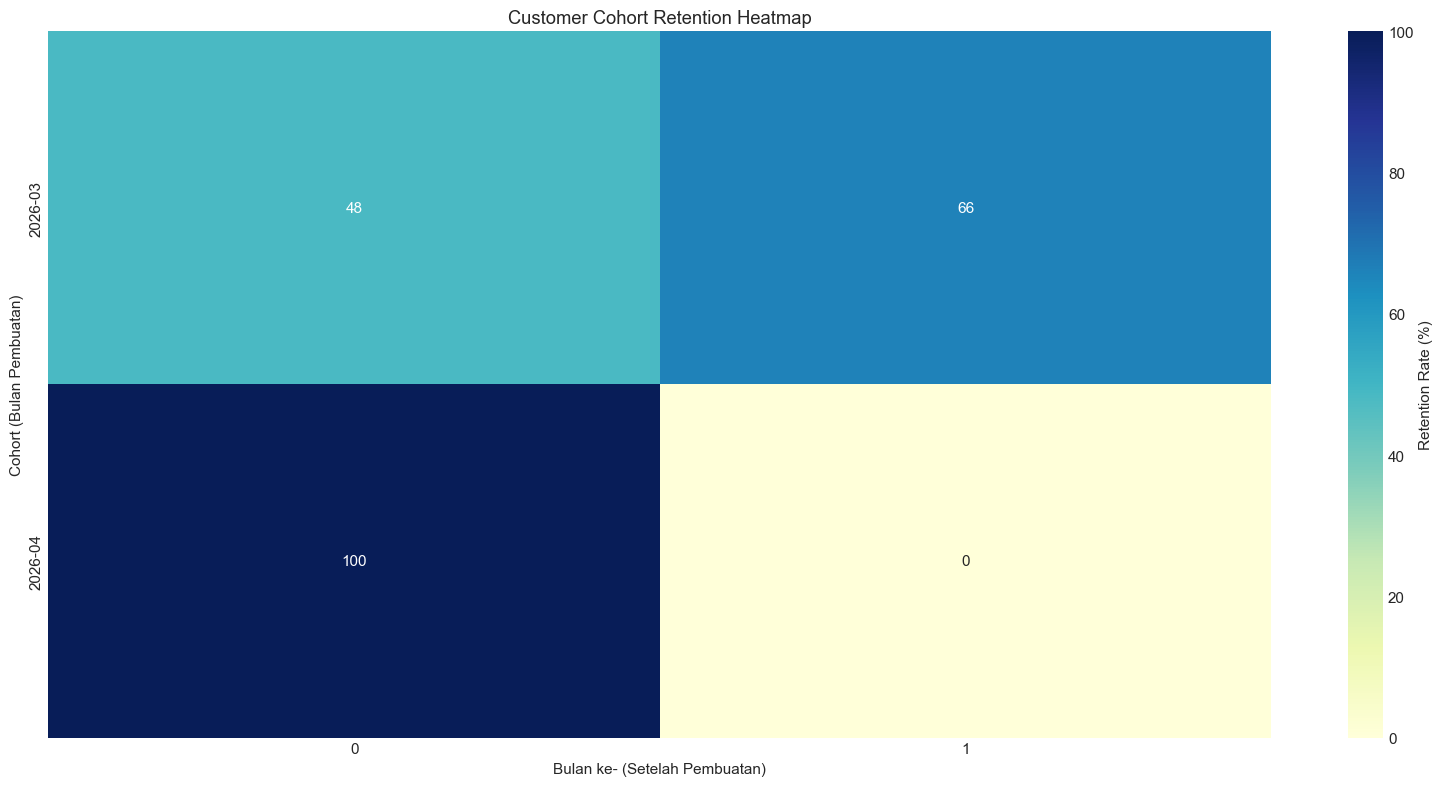

In [27]:
# Visualisasi Retention Heatmap

fig, ax = plt.subplots(figsize=(16, 8))

if len(retention_matrix) > 0:
    sns.heatmap(retention_matrix.iloc[-12:], 
                annot=True, fmt='.0f', 
                cmap='YlGnBu',
                ax=ax,
                cbar_kws={'label': 'Retention Rate (%)'})
    
    ax.set_xlabel('Bulan ke- (Setelah Pembuatan)')
    ax.set_ylabel('Cohort (Bulan Pembuatan)')
    ax.set_title('Customer Cohort Retention Heatmap')
    
    plt.tight_layout()
    plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Tidak ada data cohort yang cukup untuk ditampilkan")

## 6. Breakdown per Ukuran Outlet

In [28]:
# Tentukan kolom ukuran outlet
outlet_col = None
for col in ['ukuranOutlet', 'ukuran_outlet', 'size']:
    if col in df_customers.columns:
        outlet_col = col
        break

if outlet_col:
    outlet_breakdown = df_customers.groupby(outlet_col).agg(
        total=('id', 'count'),
        new_30d=('createdAt', lambda x: (x >= now - timedelta(days=30)).sum()),
        new_90d=('createdAt', lambda x: (x >= now - timedelta(days=90)).sum())
    ).reset_index()
    
    outlet_breakdown['pct'] = (outlet_breakdown['total'] / outlet_breakdown['total'].sum() * 100).round(1)
    outlet_breakdown = outlet_breakdown.sort_values('total', ascending=False)
    
    print(f"🏪 Breakdown Customer berdasarkan Ukuran Outlet (kolom: {outlet_col}):")
    outlet_breakdown
else:
    print("⚠️ Kolom ukuran outlet tidak ditemukan")
    outlet_breakdown = pd.DataFrame()

🏪 Breakdown Customer berdasarkan Ukuran Outlet (kolom: ukuranOutlet):


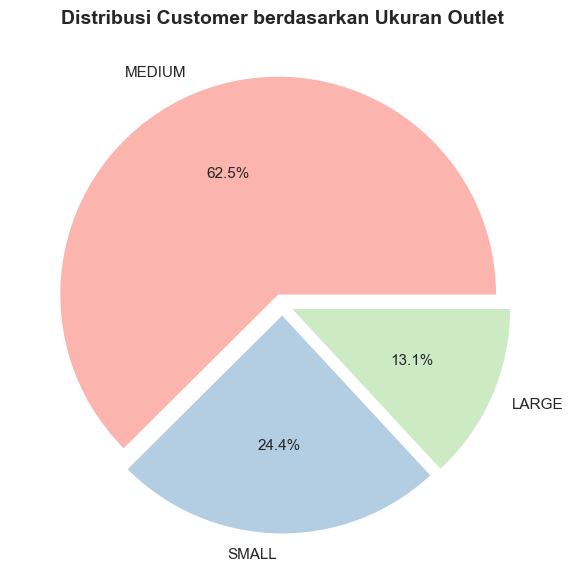

In [29]:
# Visualisasi Outlet Breakdown

if not outlet_breakdown.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.Pastel1(range(len(outlet_breakdown)))
    wedges, texts, autotexts = ax.pie(
        outlet_breakdown['total'], 
        labels=outlet_breakdown[outlet_col],
        autopct='%1.1f%%',
        colors=colors,
        explode=[0.05] * len(outlet_breakdown)
    )
    
    ax.set_title('Distribusi Customer berdasarkan Ukuran Outlet', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('customer_by_outlet_size.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Breakdown per Kota

In [30]:
# Tentukan kolom kota
kota_col = None
for col in ['kota', 'Kota', 'city']:
    if col in df_customers.columns:
        kota_col = col
        break

if kota_col:
    kota_breakdown = df_customers.groupby(kota_col).agg(
        total=('id', 'count'),
        new_30d=('createdAt', lambda x: (x >= now - timedelta(days=30)).sum())
    ).reset_index()
    
    kota_breakdown = kota_breakdown.sort_values('total', ascending=False).head(20)
    
    print(f"🏙️ Top 20 Kota:")
    kota_breakdown
else:
    print("⚠️ Kolom kota tidak ditemukan")

🏙️ Top 20 Kota:


## 8. Ringkasan KPI

In [31]:
# KPI Summary

print("=" * 70)
print("📊 RINGKASAN KPI CUSTOMER BARU")
print("=" * 70)

total_customers = len(df_customers)
new_30d = len(df_customers[df_customers['createdAt'] >= now - timedelta(days=30)])
new_90d = len(df_customers[df_customers['createdAt'] >= now - timedelta(days=90)])
avg_per_day_30d = new_30d / 30
avg_per_day_90d = new_90d / 90

# Growth vs previous period
prev_30d_start = now - timedelta(days=60)
prev_30d_end = now - timedelta(days=30)
prev_30d = len(df_customers[(df_customers['createdAt'] >= prev_30d_start) & (df_customers['createdAt'] < prev_30d_end)])
growth_30d = ((new_30d - prev_30d) / prev_30d * 100) if prev_30d > 0 else 0

print(f"\n📌 Total Customer: {total_customers:,}")
print(f"📅 Customer Baru 30 Hari: {new_30d} ({growth_30d:+.1f}% vs periode sebelumnya)")
print(f"📆 Customer Baru 90 Hari: {new_90d}")
print(f"\n📈 Rata-rata acquisition per hari (30 hari): {avg_per_day_30d:.1f} customer/hari")
print(f"📈 Rata-rata acquisition per hari (90 hari): {avg_per_day_90d:.1f} customer/hari")

# Top channel
if not channel_breakdown.empty:
    top_channel = channel_breakdown.iloc[0]
    print(f"\n🏆 Top Channel: {top_channel[channel_col]} ({top_channel['pct_from_total']}%)")

# Top province
if not province_breakdown.empty:
    top_province = province_breakdown.iloc[0]
    print(f"🌏 Top Provinsi: {top_province[province_col]} ({top_province['total_customers']} customer)")

print("\n" + "=" * 70)

📊 RINGKASAN KPI CUSTOMER BARU

📌 Total Customer: 4,225
📅 Customer Baru 30 Hari: 156 (-96.2% vs periode sebelumnya)
📆 Customer Baru 90 Hari: 4225

📈 Rata-rata acquisition per hari (30 hari): 5.2 customer/hari
📈 Rata-rata acquisition per hari (90 hari): 46.9 customer/hari

🏆 Top Channel: LAINNYA (20.93%)
🌏 Top Provinsi: Daerah Istimewa Yogyakarta (440 customer)



## 9. Export Laporan

In [32]:
# Export hasil ke Excel

report_path = os.path.join(base_path, 'new_customer_analysis_report.xlsx')

with pd.ExcelWriter(report_path) as writer:
    monthly_new.to_excel(writer, sheet_name='Monthly Trend', index=False)
    if not channel_breakdown.empty:
        channel_breakdown.to_excel(writer, sheet_name='By Channel', index=False)
    if not province_breakdown.empty:
        province_breakdown.to_excel(writer, sheet_name='By Province', index=False)
    if not outlet_breakdown.empty:
        outlet_breakdown.to_excel(writer, sheet_name='By Outlet Size', index=False)
    if not kota_breakdown.empty:
        kota_breakdown.to_excel(writer, sheet_name='By Kota', index=False)
    df_customers.to_excel(writer, sheet_name='All Customers', index=False)

print(f"✅ Laporan diexport ke: {report_path}")

✅ Laporan diexport ke: /Users/user/Documents/03 KERJA/PT Multimedia Solusi Prima/2026/APRIL/Arbas Market Intelligence - Data/Dashboardanlys/new_customer_analysis_report.xlsx


In [35]:
# Filter customer baru 30 hari terakhir
cols = ['id', 'customerCode', 'nama', 'alamat', 'type', 'umur', 'jenisKelamin', 
        'provinsi', 'kota', 'contactPerson', 'telp', 'tipeChannel', 'ukuranOutlet', 
        'capacityM3PerMonth', 'awalKontrak', 'akhirKontrak', 'status', 'featureId', 
        'geom', 'createdAt', 'updatedAt', 'createdById', 'days_since_creation', 'year_month']

In [36]:
# Filter customer baru 90 hari terakhir
df_90d = df_customers[df_customers['createdAt'] >= now - timedelta(days=90)][cols].copy()
df_90d = df_90d.sort_values('createdAt', ascending=False).reset_index(drop=True)

print(f"📊 CUSTOMER BARU 90 HARI TERAKHIR: {len(df_90d)} customer")
print(f"📅 Periode: {(now - timedelta(days=90)).strftime('%Y-%m-%d')} s/d {now.strftime('%Y-%m-%d')}")
print("\n" + "=" * 80)
df_90d

📊 CUSTOMER BARU 90 HARI TERAKHIR: 4225 customer
📅 Periode: 2026-01-28 s/d 2026-04-28



,id,customerCode,nama,alamat,type,umur,jenisKelamin,provinsi,kota,contactPerson,telp,tipeChannel,ukuranOutlet,capacityM3PerMonth,awalKontrak,akhirKontrak,status,featureId,geom,createdAt,updatedAt,createdById,days_since_creation,year_month
0,c5173a38-35cb-4ed4-b569-08cb8b19652a,BONAT001,NATHAN OFFSIDE,Jakal,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004219,NaN,2026-04-13 03:06:19.940,2026-04-13 03:06:19.94,c839fe99-ec2c-4b7e-814a-60d399884231,15,2026-04
1,6c5612f6-abb7-4613-af1c-2bd57f8ca1a3,BOMIP001,MI PANDANARAN,Pandanaran,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,SEKOLAH,NaN,0.0,NaN,NaN,active,1004218,NaN,2026-04-13 02:20:53.670,2026-04-13 02:20:53.67,c839fe99-ec2c-4b7e-814a-60d399884231,15,2026-04
2,0e1b186b-32e1-418d-8944-7537e28d79ea,BOSPP010,SPPG KALASAN 2,Kalasan,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004217,NaN,2026-04-11 11:37:15.735,2026-04-11 11:37:15.735,c839fe99-ec2c-4b7e-814a-60d399884231,17,2026-04
3,c727e23f-3f6f-4806-bdf6-bb974dc36a2a,BOSPP009,SPPG NGAGLIK 2,Ngaglik,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004216,NaN,2026-04-11 09:46:25.235,2026-04-11 09:46:25.235,c839fe99-ec2c-4b7e-814a-60d399884231,17,2026-04
4,fd8b7537-817a-4d22-8703-535bf44fa448,BOTUM001,TUMBUH BERSAMA,Maguwoharjo,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004215,NaN,2026-04-11 09:07:15.775,2026-04-11 09:07:15.775,c839fe99-ec2c-4b7e-814a-60d399884231,17,2026-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,42175cb7-caaf-4343-b18a-e650f1e0c23f,BHGRI001,GRIYA JOGJA HOTEL,"Jl. Pakuningratan No.3, Cokrodiningratan, Kec....",B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kota Yogyakarta,NaN,NaN,HOTEL,MEDIUM,0.0,2026-01-01 00:00:00,2028-01-01 00:00:00,active,1000005,0101000020E6100000295C8FC275975B40F2D24D621020...,2026-03-06 06:49:39.774,2026-03-10 03:36:08.808,31499f31-7d13-475d-a8c8-880d4bf09cf4,53,2026-03
4221,51c93bbe-6ab3-44fe-a50a-2b8983944425,BFRMR001,RM RATA-RATA PALAGAN,"JL. PALAGAN TENTARA PELAJAR, TEGALREJO, SARIHA...",B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Sleman,NaN,NaN,RESTORAN,MEDIUM,0.0,2026-01-01 00:00:00,2028-01-01 00:00:00,active,1000004,0101000020E6100000F4FDD47869985B407593180456E6...,2026-03-06 06:49:39.770,2026-03-13 01:28:29.074,31499f31-7d13-475d-a8c8-880d4bf09cf4,53,2026-03
4222,45e4ad80-83d7-412a-8bcb-c80a69f1a9c1,BRGLO001,GLOBAL SUKSES,"698V+W6 Caturtunggal, Sleman Regency, Special ...",B2B,NaN,NaN,Daerah Istimewa Yogyakarta,SLEMAN,NaN,NaN,RETAIL,MEDIUM,0.0,2026-01-01 00:00:00,2028-01-01 00:00:00,active,1000003,0101000020E61000002DB29DEF27995B40B6F3FDD47821...,2026-03-06 06:49:39.766,2026-03-12 01:26:33.611,31499f31-7d13-475d-a8c8-880d4bf09cf4,53,2026-03
4223,3ac8f3e5-0ab4-4429-9e49-73372e594bc1,BRTOK002,TOKO TM GROSIR,"78J3+33W, Kebonagung Kasuran, Pete, Margodadi,...",B2B,NaN,NaN,NaN,NaN,NaN,NaN,RUKO_SRC,NaN,NaN,2026-01-01 00:00:00,2028-01-01 00:00:00,Active,1000002,0101000020E610000076B9D27C5F935B407E8CB96B09E1...,2026-03-06 06:49:39.763,2026-03-06 06:49:39.763,31499f31-7d13-475d-a8c8-880d4bf09cf4,53,2026-03


## 11. Detail Customer Baru - 90 Hari Terakhir

In [ ]:


df_30d = df_customers[df_customers['createdAt'] >= now - timedelta(days=30)][cols].copy()
df_30d = df_30d.sort_values('createdAt', ascending=False).reset_index(drop=True)

print(f"📊 CUSTOMER BARU 30 HARI TERAKHIR: {len(df_30d)} customer")
print(f"📅 Periode: {(now - timedelta(days=30)).strftime('%Y-%m-%d')} s/d {now.strftime('%Y-%m-%d')}")
print("\n" + "=" * 80)
df_30d

📊 CUSTOMER BARU 30 HARI TERAKHIR: 156 customer
📅 Periode: 2026-03-29 s/d 2026-04-28



,id,customerCode,nama,alamat,type,umur,jenisKelamin,provinsi,kota,contactPerson,telp,tipeChannel,ukuranOutlet,capacityM3PerMonth,awalKontrak,akhirKontrak,status,featureId,geom,createdAt,updatedAt,createdById,days_since_creation,year_month
0,c5173a38-35cb-4ed4-b569-08cb8b19652a,BONAT001,NATHAN OFFSIDE,Jakal,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004219,NaN,2026-04-13 03:06:19.940,2026-04-13 03:06:19.94,c839fe99-ec2c-4b7e-814a-60d399884231,15,2026-04
1,6c5612f6-abb7-4613-af1c-2bd57f8ca1a3,BOMIP001,MI PANDANARAN,Pandanaran,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,SEKOLAH,NaN,0.0,NaN,NaN,active,1004218,NaN,2026-04-13 02:20:53.670,2026-04-13 02:20:53.67,c839fe99-ec2c-4b7e-814a-60d399884231,15,2026-04
2,0e1b186b-32e1-418d-8944-7537e28d79ea,BOSPP010,SPPG KALASAN 2,Kalasan,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004217,NaN,2026-04-11 11:37:15.735,2026-04-11 11:37:15.735,c839fe99-ec2c-4b7e-814a-60d399884231,17,2026-04
3,c727e23f-3f6f-4806-bdf6-bb974dc36a2a,BOSPP009,SPPG NGAGLIK 2,Ngaglik,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004216,NaN,2026-04-11 09:46:25.235,2026-04-11 09:46:25.235,c839fe99-ec2c-4b7e-814a-60d399884231,17,2026-04
4,fd8b7537-817a-4d22-8703-535bf44fa448,BOTUM001,TUMBUH BERSAMA,Maguwoharjo,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,LAINNYA,NaN,0.0,NaN,NaN,active,1004215,NaN,2026-04-11 09:07:15.775,2026-04-11 09:07:15.775,c839fe99-ec2c-4b7e-814a-60d399884231,17,2026-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,3eed71f1-f4ff-48f9-b77f-41d3f2ae71dd,BOSUZ006,SUZUKI JL. SOLO,Jl. Solo,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,RETAIL,NaN,0.0,NaN,NaN,active,1004071,NaN,2026-04-08 03:23:21.794,2026-04-08 03:23:21.794,c839fe99-ec2c-4b7e-814a-60d399884231,20,2026-04
152,4f1ef3dc-6646-4985-9789-35e0905554e7,BOPAK005,PAK NASRULLAH,Berbah,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,RUMAH_TANGGA,NaN,0.0,NaN,NaN,active,1004070,NaN,2026-04-08 03:18:30.578,2026-04-08 03:18:30.578,c839fe99-ec2c-4b7e-814a-60d399884231,20,2026-04
153,b4c1d8a5-f0c8-46d9-9cae-6567ebacad50,BOESQ005,ES QUE TIMBUL 4,BERBAH,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,TOKO,NaN,0.0,NaN,NaN,active,1004069,NaN,2026-04-08 03:13:24.826,2026-04-08 03:13:24.826,c839fe99-ec2c-4b7e-814a-60d399884231,20,2026-04
154,0651aa67-e8fd-417b-812e-c86ea8f4aa57,BOKED001,KEDAI MAKMUR,Wahid hasyim,B2B,NaN,NaN,Daerah Istimewa Yogyakarta,Kabupaten Sleman,Bcs Pss,NaN,RESTORAN,NaN,0.0,NaN,NaN,active,1004068,NaN,2026-04-08 03:02:19.813,2026-04-08 03:02:19.813,c839fe99-ec2c-4b7e-814a-60d399884231,20,2026-04


## 10. Detail Customer Baru - 30 Hari Terakhir